In [29]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns  # for nicer plots
sns.set(style="darkgrid")  # default style

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from keras import metrics
from keras.datasets import fashion_mnist

tf.get_logger().setLevel('INFO')

In [30]:
import cv2

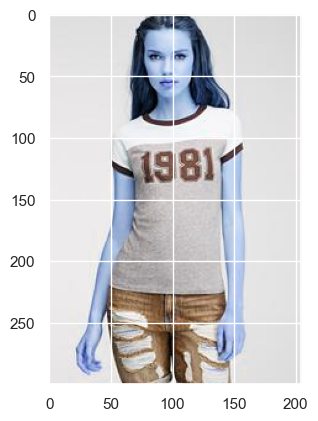

In [ ]:
# start by loading in the data from one image
test = cv2.imread('/Users/brentarakaki/Desktop/img/1981_Graphic_Ringer_Tee/img_00000001.jpg')
# test_rgb = cv2.cvtColor(test, cv2.COLOR_BGR2GRAY)
plt.imshow(test)

# plt.imshow(test / 255)

In [107]:
test.shape


(300, 205, 3)

In [ ]:
# work on making a nice way to make data more readable

import pandas as pd

# Load a space-separated or tab-separated text file
df_index = pd.read_csv("/Users/brentarakaki/Downloads/Anno_fine/train.txt", sep=" ", header= None)

df_attr = pd.read_csv("/Users/brentarakaki/Downloads/Anno_fine/train_attr.txt", sep=" ", header= None)

df_bbox = pd.read_csv("/Users/brentarakaki/Downloads/Anno_fine/train_bbox.txt", sep=" ", header= None)

df_cate = pd.read_csv("/Users/brentarakaki/Downloads/Anno_fine/train_cate.txt", sep=" ", header= None)
df_cate.columns = ['category']

df_landmarks = pd.read_csv("/Users/brentarakaki/Downloads/Anno_fine/train_landmarks.txt", sep=" ", header= None)

category = pd.read_csv("/Users/brentarakaki/Downloads/Anno_fine/list_category_cloth.txt", sep=",", header= 0)
category = category.reset_index(names='category')
category['category'] += 1


df_attr = df_attr.iloc[:, 0:26]
df_bbox = df_bbox.iloc[:, 0:4]
# df_cate =
df_landmarks = df_landmarks.iloc[:, 0:16]

In [67]:
np.unique(df_cate)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 39, 40, 41, 42, 43, 44, 46, 47, 48])

In [71]:
len(df_cate)

14000

In [72]:
len(df_index)

14000

In [68]:
df_index

,0
0,img/Sweet_Crochet_Blouse/img_00000070.jpg
1,img/Classic_Pencil_Skirt/img_00000010.jpg
2,img/Strapless_Diamond_Print_Dress/img_00000038...
3,img/Mid-Rise_-_Acid_Wash_Skinny_Jeans/img_0000...
4,img/Zippered_Single-Button_Blazer/img_00000078...
...,...
13995,img/Baroque_Print_High-Neck_Romper/img_0000002...
13996,img/Crocheted_Mandala_Print_Dress/img_00000007...
13997,img/Mesh_Contrast-Pocket_Tank/img_00000031.jpg
13998,img/Classic_Toggle_Coat/img_00000025.jpg


In [75]:
df_cate.head()

,0
0,3
1,33
2,41
3,26
4,2


In [33]:
len(df_attr)

14000

In [34]:
bbox_columns = ['x_1',
                'y_1',
                'x_2',
                'y_2']

attr_columns = ['floral',
                'graphic',
                'striped',
                'embroidered',
                'pleated',
                'solid',
                'lattice',
                'long_sleeve',
                'short_sleeve',
                'sleeveless',
                'maxi_length',
                'mini_length',
                'no_dress',
                'crew_neckline',
                'v_neckline',
                'square_neckline',
                'no_neckline',
                'denim',
                'chiffon',
                'cotton',
                'leather',
                'faux',
                'knit',
                'tight',
                'loose',
                'conventional']

landmarks_columns = [
    
]



df_bbox.columns = bbox_columns
df_attr.columns = attr_columns
df_cate.columns = ['category']



In [70]:
category

,category,category_name,category_type,category_type_name
0,1,Anorak,1,upper-body
1,2,Blazer,1,upper-body
2,3,Blouse,1,upper-body
3,4,Bomber,1,upper-body
4,5,Button-Down,1,upper-body
5,6,Cardigan,1,upper-body
6,7,Flannel,1,upper-body
7,8,Halter,1,upper-body
8,9,Henley,1,upper-body
9,10,Hoodie,1,upper-body


In [98]:
df_cate_human = pd.merge(df_cate, category, on='category', how='left')
df_cate_human

,category,category_name,category_type,category_type_name
0,3,Blouse,1,upper-body
1,33,Skirt,2,lower-body
2,41,Dress,3,full-body
3,26,Jeans,2,lower-body
4,2,Blazer,1,upper-body
...,...,...,...,...
13995,48,Romper,3,full-body
13996,41,Dress,3,full-body
13997,17,Tank,1,upper-body
13998,39,Coat,3,full-body


In [101]:
df_labeled = pd.merge(df_index, df_cate, left_index=True, right_index=True, how='left')

df_labeled.columns = ['path', 'category']
df_labeled.head()

,path,category
0,img/Sweet_Crochet_Blouse/img_00000070.jpg,3
1,img/Classic_Pencil_Skirt/img_00000010.jpg,33
2,img/Strapless_Diamond_Print_Dress/img_00000038...,41
3,img/Mid-Rise_-_Acid_Wash_Skinny_Jeans/img_0000...,26
4,img/Zippered_Single-Button_Blazer/img_00000078...,2


In [123]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Rescale images from [0, 255] to [0, 1]
generator = ImageDataGenerator(rescale=1/255)

In [134]:
base_dir = "/Users/brentarakaki/Desktop/"

training_generator = generator.flow_from_dataframe(
    dataframe = df_labeled, directory = base_dir,
    x_col = "path", y_col = "category",
    subset="training", class_mode = "raw",
    target_size = (224, 224),
    batch_size=32
)

Found 14000 validated image filenames.


In [114]:
training_generator


In [ ]:
df_assignment = pd.read_csv("/Users/brentarakaki/Downloads/Anno_fine/list_eval_partition.txt", sep=r'\s+', header= 1)

In [ ]:
df_assignment

In [135]:

def build_model(n_classes,
                hidden_layer_sizes=[],
                activation='relu',
                optimizer='SGD',
                learning_rate=0.01,
                metric='metric'):
    """Build a multi-class logistic regression model using Keras.

    Args:
    n_classes: Number of output classes in the dataset.
    hidden_layer_sizes: A list with the number of units in each hidden layer.
    activation: The activation function to use for the hidden layers.
    optimizer: The optimizer to use (SGD, Adam).
    learning_rate: The desired learning rate for the optimizer. (goes into modile compile)
    metric: The desired metric. (goes into model compile)

    Returns:
    model: A tf.keras model (graph).
    """
    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)

    # YOUR CODE HERE
    model = tf.keras.Sequential() # start by initializing the model
    
    model.add(tf.keras.Input(shape=(224, 224, 3), name= 'Input')) # define shape of input, each image is 28 x 28

    model.add(tf.keras.layers.Flatten()) # flatten images to allow layer to handle

    # create hidden layers based on hidden_layer_sizes list
    for size in hidden_layer_sizes:
        model.add(tf.keras.layers.Dense(units=size, activation=activation))

    # output layer with softmax to allow for multiclass classification
    model.add(tf.keras.layers.Dense(units = n_classes, activation= 'softmax', name= 'Output'))

    # create an optimizer based on input parameter and learning rate
    if optimizer == 'SGD':
        model_optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer == 'Adam':
        model_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        raise ValueError("Choose different optimizer, SGD or Adam (case sensitive)")

    # compile the model
    model.compile(loss= tf.keras.losses.SparseCategoricalCrossentropy(from_logits= False), 
                  optimizer= model_optimizer, metrics = [metric])

    return model

In [ ]:
model = build_model(n_classes = 50, hidden_layer_sizes=[128], activation='relu',
                optimizer='SGD',
                learning_rate=0.01,
                metric='sparse_categorical_accuracy')

In [136]:
model.fit(training_generator,       # Keras automatically loops through this generator
    epochs=10,
    steps_per_epoch=len(training_generator))

Epoch 1/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step - loss: 4.0418 - sparse_categorical_accuracy: 0.2796
Epoch 2/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 29s 66ms/step - loss: 3.3859 - sparse_categorical_accuracy: 0.2869
Epoch 3/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - loss: 3.1861 - sparse_categorical_accuracy: 0.2869
Epoch 4/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 26s 59ms/step - loss: 3.0793 - sparse_categorical_accuracy: 0.2869
Epoch 5/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 39s 89ms/step - loss: 3.0143 - sparse_categorical_accuracy: 0.2869
Epoch 6/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 37s 84ms/step - loss: 2.9677 - sparse_categorical_accuracy: 0.2869
Epoch 7/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 27s 62ms/step - loss: 2.9315 - sparse_categorical_accuracy: 0.2869
Epoch 8/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - loss: 2.9075 - sparse_categorical_accuracy: 0.2869
Epoch 9/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 24s 54ms/step - loss: 2.8788 - sparse_categorical_accuracy: 0.2869
Epoch 10/10
438/438 ━━━━━━━━━━━━━━━━━

In [ ]:
plt.figure()

fig, axs = plt.subplots(nrows=50, ncols=3, figsize=(25, 300))

for i in range(0, 50):
    image = df_labeled[df_labeled['category'] == i+1]['path']
    axs[i,0].set_ylabel(category['category_name'][i], fontsize = 20)

    if len(image) > 3:
        for j in range(0, 3):
            directory = base_dir + image.iloc[j]
            inter = cv2.imread(directory)
            axs[i, j].imshow(inter)

    else:
        for j in range(0, len(image)):
            directory = base_dir + image.iloc[j]
            inter = cv2.imread(directory)
            axs[i, j].imshow(inter)

fig.suptitle('First 3 examples of each type in Training Data', fontsize=40, y=1)

fig.tight_layout()
plt.show()


In [196]:
for i in range(0, 50):
    image = df_labeled[df_labeled['category'] == i+1]['path']
    name = category['category_name'][i]

    print(f"{name}: {len(image)}")

Anorak: 9
Blazer: 367
Blouse: 1055
Bomber: 16
Button-Down: 9
Cardigan: 635
Flannel: 6
Halter: 1
Henley: 45
Hoodie: 201
Jacket: 476
Jersey: 40
Parka: 26
Peacoat: 2
Poncho: 35
Sweater: 557
Tank: 726
Tee: 1621
Top: 534
Turtleneck: 11
Capris: 7
Chinos: 28
Culottes: 34
Cutoffs: 71
Gauchos: 0
Jeans: 344
Jeggings: 29
Jodhpurs: 3
Joggers: 200
Leggings: 232
Sarong: 3
Shorts: 822
Skirt: 680
Sweatpants: 116
Sweatshorts: 58
Trunks: 17
Caftan: 1
Cape: 0
Coat: 115
Coverup: 2
Dress: 4016
Jumpsuit: 351
Kaftan: 8
Kimono: 143
Nightdress: 0
Onesie: 5
Robe: 3
Romper: 340
Shirtdress: 0
Sundress: 0
